In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
# Load cleaned dataset
terror_df = pd.read_csv(
    "../data/processed/terrorism_cleaned.csv",
    parse_dates=["date"]
)

terror_df.head()

,eventid,iyear,imonth,iday,country_txt,region_txt,provstate,city,latitude,longitude,...,gname,weaptype1_txt,nkill,nwound,date,casualties,attack_success,suicide_attack,decade,high_casualty
0,197000000001,1970,7,2,Dominican Republic,Central America & Caribbean,National,Santo Domingo,18.456792,-69.951164,...,MANO-D,Unknown,1.0,0.0,1970-07-02,1.0,Successful,No,1970s,No
1,197000000002,1970,1,1,Mexico,North America,Federal,Mexico city,19.371887,-99.086624,...,23rd of September Communist League,Unknown,0.0,0.0,1970-01-01,0.0,Successful,No,1970s,No
2,197001000001,1970,1,1,Philippines,Southeast Asia,Tarlac,Unknown,15.478598,120.599741,...,Unknown Group,Unknown,1.0,0.0,1970-01-01,1.0,Successful,No,1970s,No
3,197001000002,1970,1,1,Greece,Western Europe,Attica,Athens,37.997490,23.762728,...,Unknown Group,Explosives,0.0,0.0,1970-01-01,0.0,Successful,No,1970s,No
4,197001000003,1970,1,1,Japan,East Asia,Fukouka,Fukouka,33.580412,130.396361,...,Unknown Group,Incendiary,0.0,0.0,1970-01-01,0.0,Successful,No,1970s,No


In [5]:
# Display dataset dimensions
terror_df.shape

(209706, 25)

In [6]:
# Display data information
terror_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209706 entries, 0 to 209705
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   eventid          209706 non-null  int64         
 1   iyear            209706 non-null  int64         
 2   imonth           209706 non-null  int64         
 3   iday             209706 non-null  int64         
 4   country_txt      209706 non-null  object        
 5   region_txt       209706 non-null  object        
 6   provstate        209706 non-null  object        
 7   city             209706 non-null  object        
 8   latitude         205015 non-null  float64       
 9   longitude        205014 non-null  float64       
 10  summary          209706 non-null  object        
 11  success          209706 non-null  int64         
 12  suicide          209706 non-null  int64         
 13  attacktype1_txt  209706 non-null  object        
 14  targtype1_txt    209

In [7]:
# Calculate incidents per year
incidents_per_year = (
    terror_df
    .groupby("iyear")
    .size()
    .reset_index(name="incidents")
)

incidents_per_year.head()

,iyear,incidents
0,1970,651
1,1971,471
2,1972,567
3,1973,473
4,1974,581


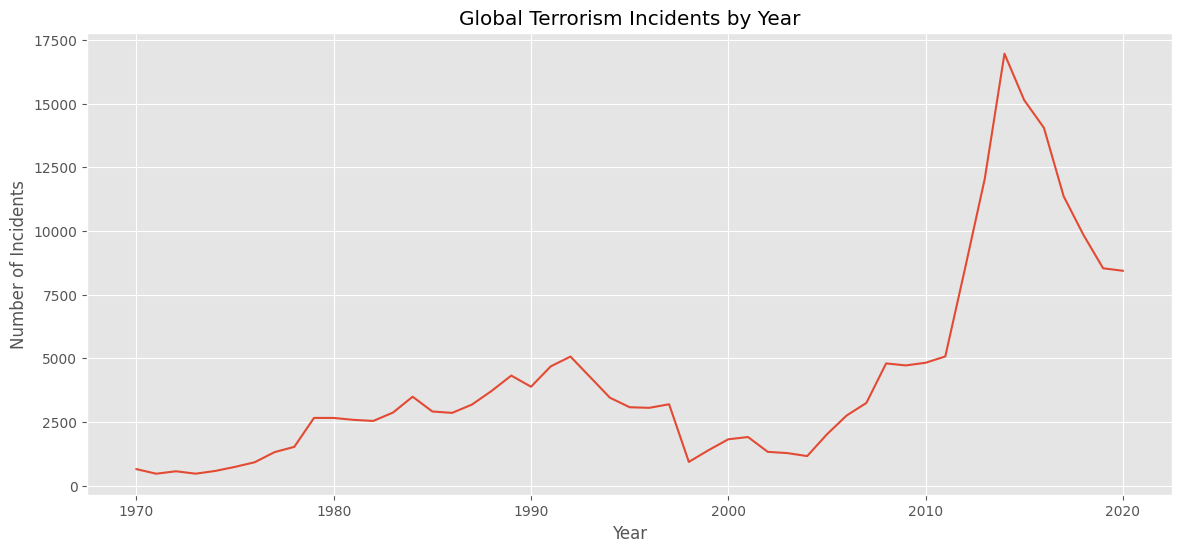

In [8]:
# Plot incidents over time
plt.figure(figsize=(14,6))

plt.plot(
    incidents_per_year["iyear"],
    incidents_per_year["incidents"]
)

plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.title("Global Terrorism Incidents by Year")

plt.show()

In [9]:
# Top 20 countries by number of incidents
top_countries = (
    terror_df["country_txt"]
    .value_counts()
    .head(20)
)

top_countries

country_txt
Iraq              27521
Afghanistan       18920
Pakistan          15504
India             13929
Colombia           8915
Philippines        8271
Peru               6111
Yemen              6027
Nigeria            5550
United Kingdom     5513
El Salvador        5320
Somalia            5317
Turkey             4485
Thailand           4201
Spain              3255
United States      3121
Sri Lanka          3041
Syria              2997
Algeria            2753
France             2751
Name: count, dtype: int64

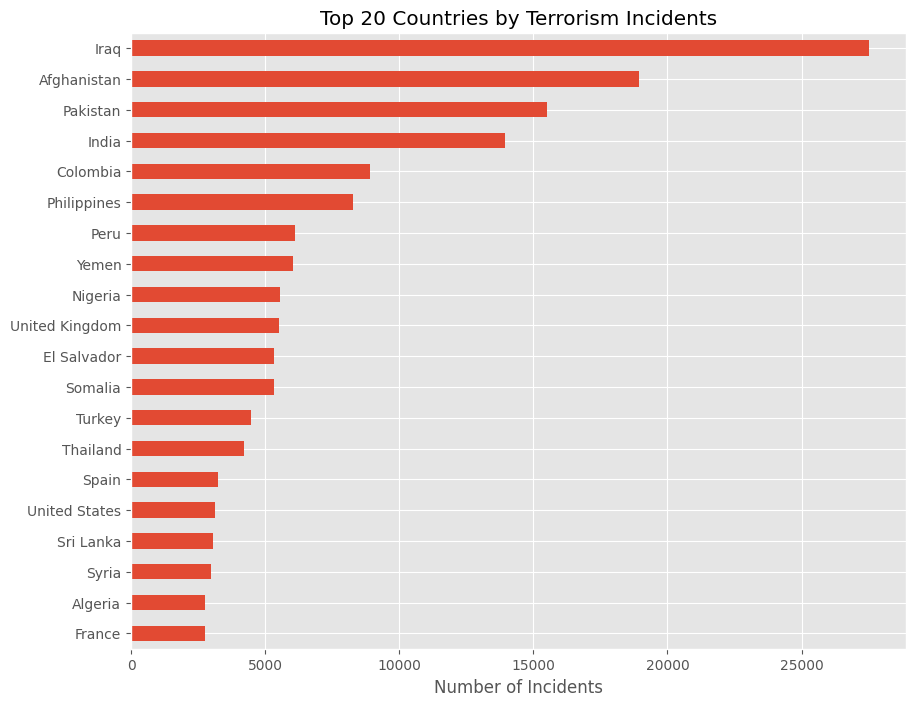

In [10]:
# Plot top countries
plt.figure(figsize=(10,8))

top_countries.sort_values().plot(kind="barh")

plt.xlabel("Number of Incidents")
plt.ylabel("")
plt.title("Top 20 Countries by Terrorism Incidents")

plt.show()

In [11]:
# Count attack types excluding "unknown"
attack_types = (
    terror_df[
        terror_df["attacktype1_txt"] != "Unknown"
    ]["attacktype1_txt"]
    .value_counts()
)

attack_types

attacktype1_txt
Bombing/Explosion                      98158
Armed Assault                          49553
Assassination                          21539
Hostage Taking (Kidnapping)            14045
Facility/Infrastructure Attack         12325
Unarmed Assault                         1229
Hostage Taking (Barricade Incident)     1156
Hijacking                                759
Name: count, dtype: int64

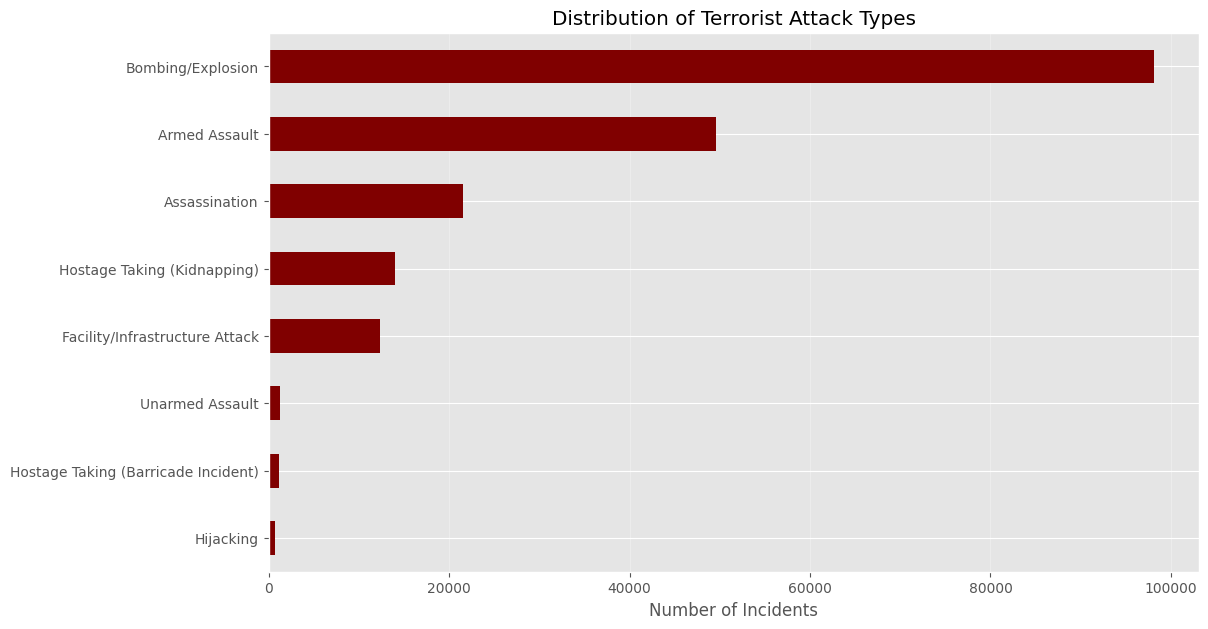

In [12]:
# Plot attack types
plt.figure(figsize=(12,7))

attack_types.sort_values().plot(kind="barh", color="maroon")

plt.xlabel("Number of Incidents")
plt.ylabel("")
plt.title("Distribution of Terrorist Attack Types")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [13]:
# Top 5 weapon types
weapon_types = (
    terror_df[
        terror_df["weaptype1_txt"] != "Unknown"
    ]["weaptype1_txt"]
    .value_counts().head(5)
)
weapon_types

weaptype1_txt
Explosives    103475
Firearms       67648
Incendiary     13133
Melee           4307
Chemical         347
Name: count, dtype: int64

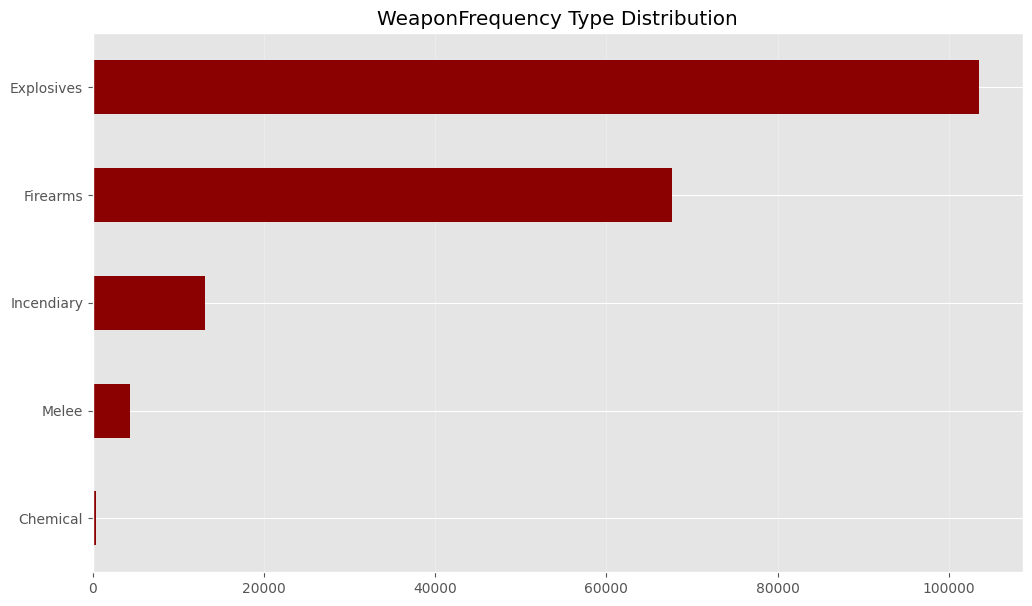

In [14]:
# Plot top 5 weapon type distribution

plt.figure(figsize=(12,7))

weapon_types.sort_values().plot(kind="barh", color="darkred")

plt.ylabel("")
plt.title("WeaponFrequency Type Distribution")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [15]:
# Count target types
target_types = (
    terror_df[
        terror_df["targtype1_txt"] != "Unknown"
    ]["targtype1_txt"]
    .value_counts()
)
target_types

targtype1_txt
Private Citizens & Property       51985
Military                          34131
Police                            28568
Government (General)              23828
Business                          22169
Transportation                     7173
Utilities                          6328
Religious Figures/Institutions     5107
Educational Institution            4761
Government (Diplomatic)            3802
Terrorists/Non-State Militia       3775
Journalists & Media                3313
Violent Political Party            2079
Airports & Aircraft                1428
Telecommunication                  1275
NGO                                1128
Tourists                            460
Maritime                            406
Food or Water Supply                352
Abortion Related                    267
Other                               197
Name: count, dtype: int64

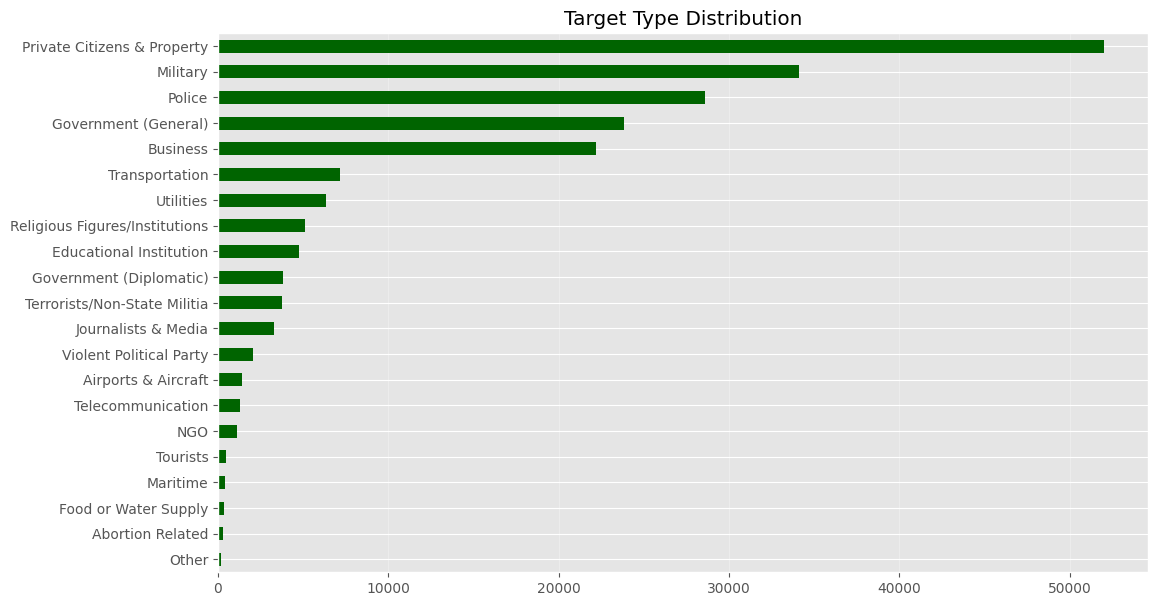

In [16]:
# Plot target type distribution
plt.figure(figsize=(12,7))

target_types.sort_values().plot(kind="barh",color="darkgreen")

plt.ylabel("")
plt.title("Target Type Distribution")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [17]:
# Exclude unknown groups
top_groups = (
    terror_df[
        terror_df["gname"] != "Unknown Group"
    ]
    ["gname"]
    .value_counts()
    .head(20)
)

top_groups

gname
Taliban                                             11982
Islamic State of Iraq and the Levant (ISIL)          7254
Shining Path (SL)                                    4564
Al-Shabaab                                           4419
New People's Army (NPA)                              3395
Farabundo Marti National Liberation Front (FMLN)     3351
Boko Haram                                           3320
Houthi extremists (Ansar Allah)                      3196
Irish Republican Army (IRA)                          2670
Kurdistan Workers' Party (PKK)                       2582
Revolutionary Armed Forces of Colombia (FARC)        2490
Communist Party of India - Maoist (CPI-Maoist)       2093
Maoists                                              2091
Basque Fatherland and Freedom (ETA)                  2024
National Liberation Army of Colombia (ELN)           1815
Liberation Tigers of Tamil Eelam (LTTE)              1602
Tehrik-i-Taliban Pakistan (TTP)                      1490
Palestin

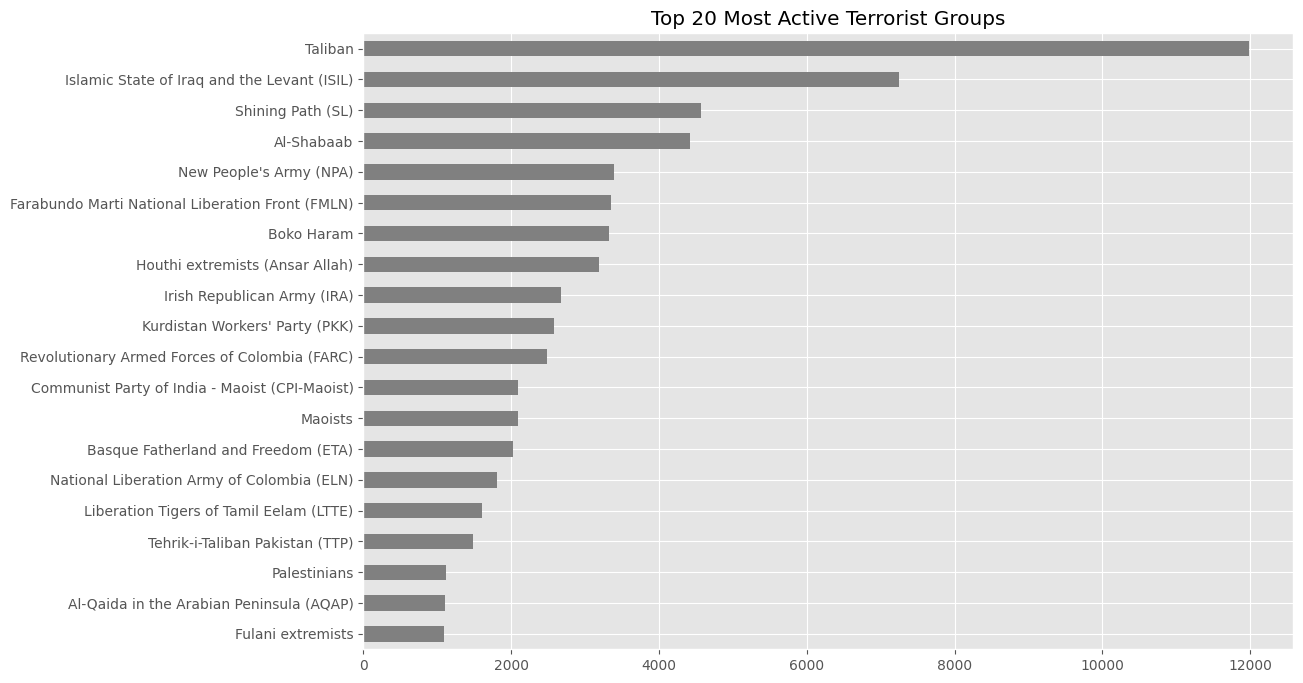

In [18]:
# Plot top groups
plt.figure(figsize=(12,8))

top_groups.sort_values().plot(kind="barh", color="grey")

plt.ylabel("")
plt.title("Top 20 Most Active Terrorist Groups")

plt.show()

In [19]:
# Calculate fatalities by region
fatalities_region = (
    terror_df
    .groupby("region_txt")["nkill"]
    .sum()
    .sort_values(ascending=False)
)

fatalities_region

region_txt
Middle East & North Africa     149739.0
South Asia                     132037.0
Sub-Saharan Africa             100557.0
South America                   29388.0
Central America & Caribbean     28730.0
Southeast Asia                  17109.0
Eastern Europe                   7483.0
Western Europe                   6709.0
North America                    5153.0
East Asia                        1154.0
Central Asia                     1084.0
Australasia & Oceania             205.0
Name: nkill, dtype: float64

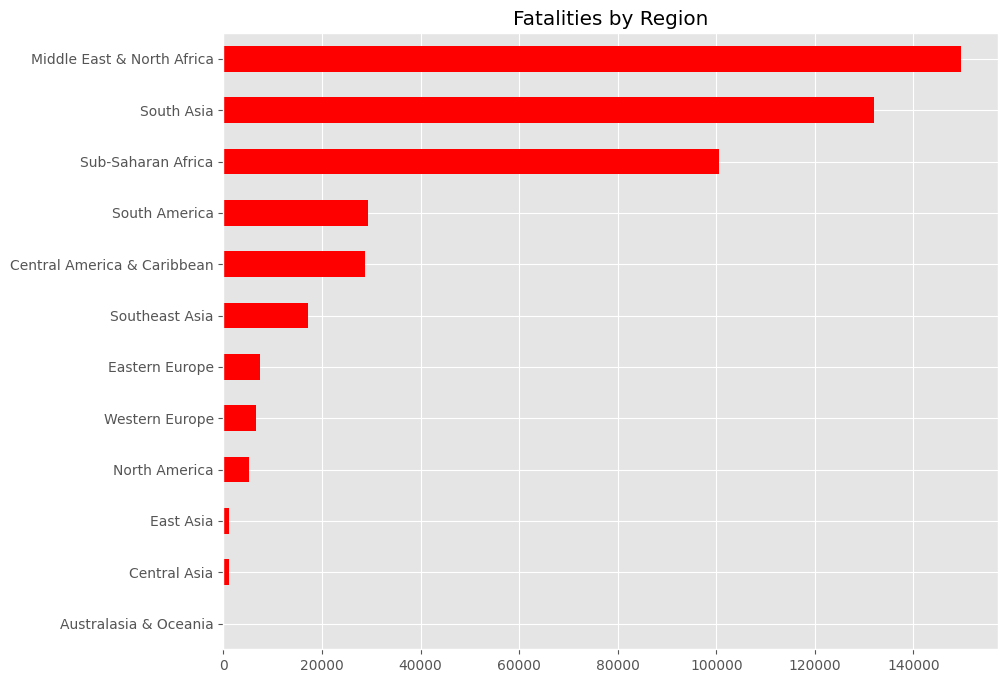

In [20]:
# Plot fatalities by region
plt.figure(figsize=(10,8))

fatalities_region.sort_values().plot(kind="barh", color="red")

plt.ylabel("")
plt.title("Fatalities by Region")

plt.show()